✅ Columns in the CSV:
['Nombre punto de monitoreo', 'fecha de monitoreo', 'código de muestra', 'Oxígeno Disuelto mg O2/L', 'Temperatura °C', 'Conductividad Eléctrica uS/cm', 'Demanda Química de Oxígeno mg/L', 'pH unidades de pH', 'Sólidos Suspendidos Totales mg/L', 'Nitrógeno  Total mg /L', 'Fósforo Total  mg/L', 'Nitratos (mg N-NO3-/L)']

✅ Detected columns:
date  = fecha de monitoreo
temp  = Temperatura °C
ph    = pH unidades de pH
ce    = Conductividad Eléctrica uS/cm
no3n  = Nitratos (mg N-NO3-/L)

📌 Final modeling dataset shape: (166, 5)
        date  temp    ph    ce   no3n
0 2006-04-17  19.7  7.24  60.6  0.069
1 2006-06-06  18.9  6.60  61.0  0.130
2 2007-04-17  19.7  6.52  54.6  0.320
3 2007-07-18  20.6  6.69  60.4  0.037
4 2008-05-22  18.7  7.67  59.0  0.046

✅ Temporal split:
  Train: 129 (2008-05-22 → 2020-09-19)
  Test : 33 (2020-09-20 → 2023-11-15)

✅ RESULTS (XGBoost with temporal features)
MAE : 0.085111
RMSE: 0.115649
R2  : 0.371631

🧪 STABILITY CHECK (same holdout, diff

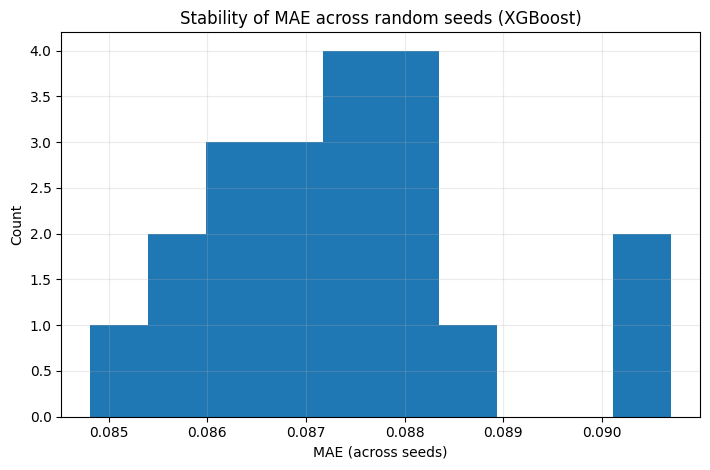


📉 BASELINES (HOLDOUT TEST)
Baseline Mean:
  MAE : 0.127236
  RMSE: 0.149902
  R2  : -0.055709
Baseline Naive Last (t-1):
  MAE : 0.122667
  RMSE: 0.164546
  R2  : -0.272047

📌 SUMMARY (TEST)
                 Model       MAE      RMSE        R2
0              XGBoost  0.085111  0.115649  0.371631
1        Baseline Mean  0.127236  0.149902 -0.055709
2  Baseline Naive(t-1)  0.122667  0.164546 -0.272047


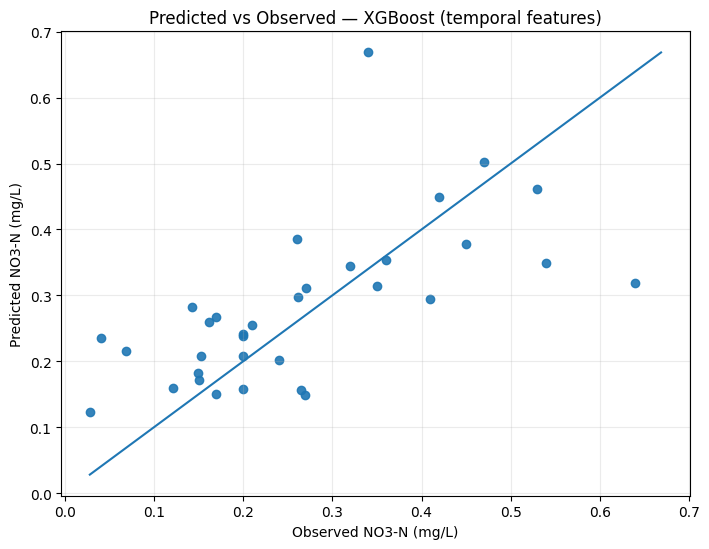

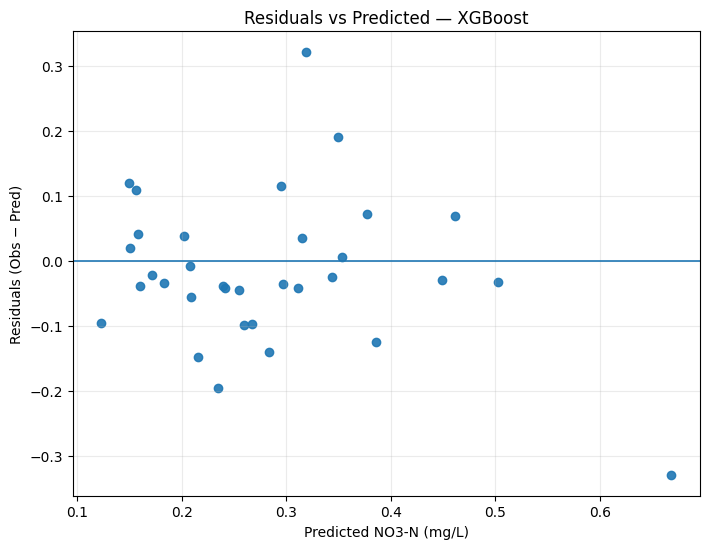

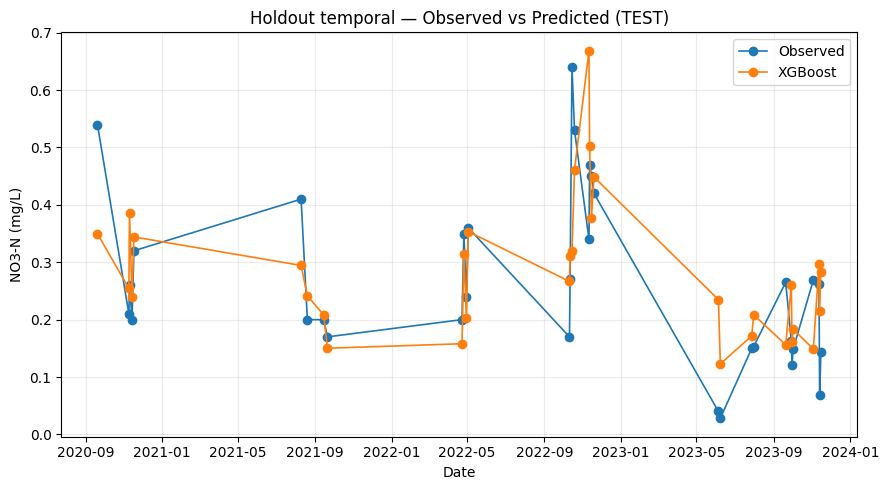

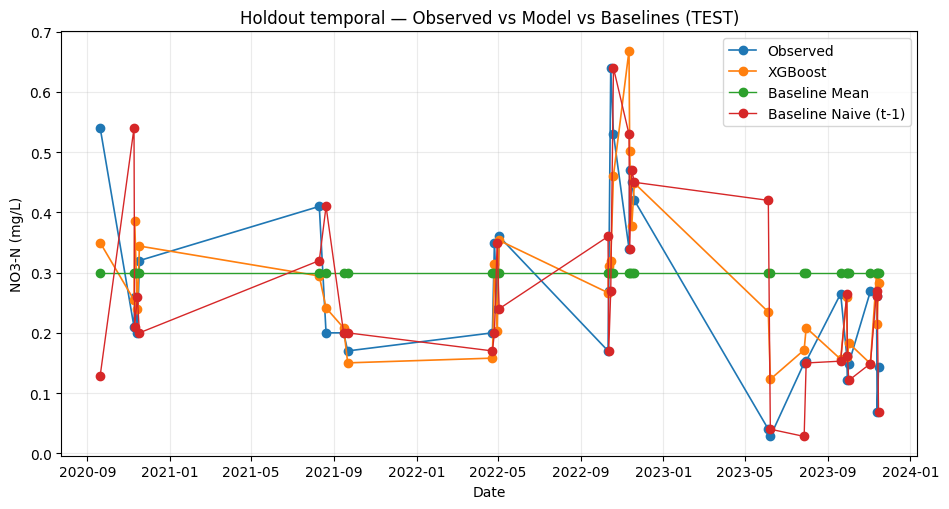


📌 Permutation importance (TEST) — top 15
      feature  perm_importance_mean  perm_importance_std
0  no3n_roll3              0.070353             0.016620
1   no3n_lag1              0.014277             0.005915
2  no3n_roll5              0.011725             0.004449
3        temp              0.003179             0.006058
4   dayofyear              0.002889             0.002685
5          ce              0.001030             0.001941
6          ph              0.000737             0.002787
7     ce_lag1              0.000736             0.001514
8       month              0.000353             0.001100
9   temp_lag1             -0.003347             0.001008


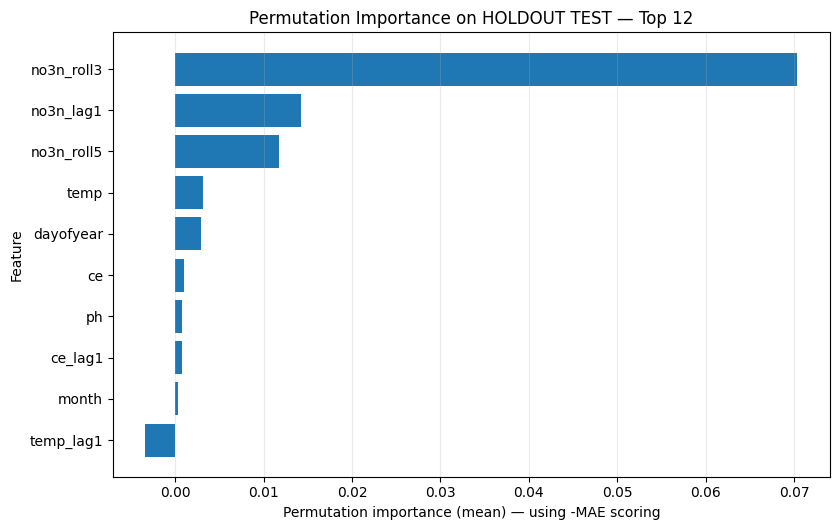

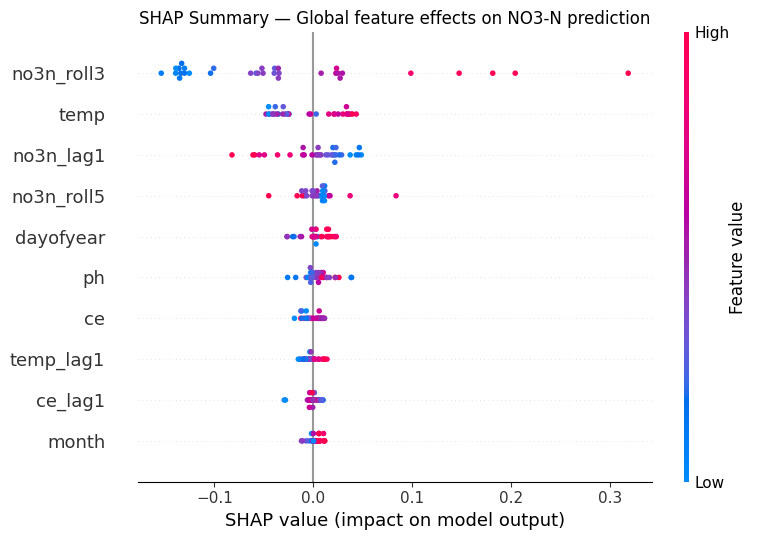

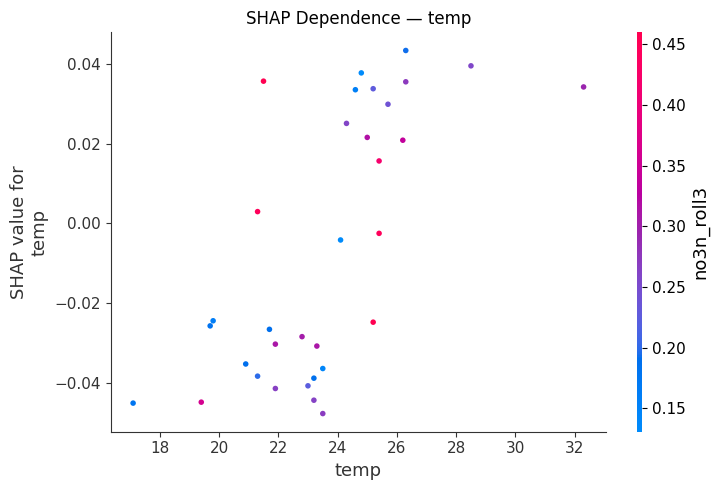

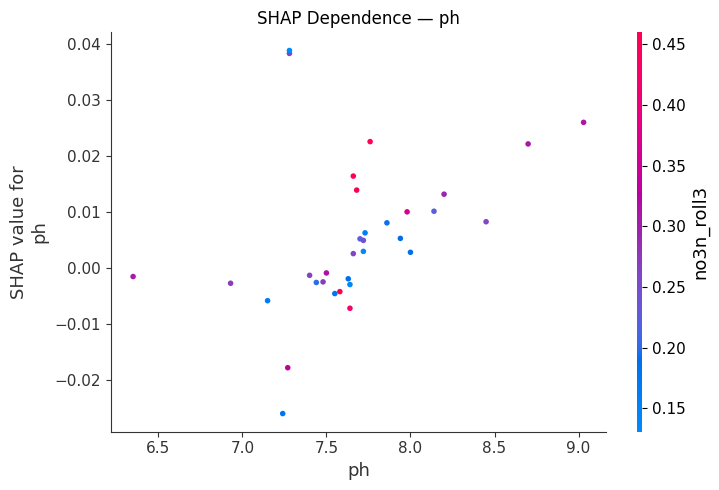

In [4]:
# ============================================================
# FULL PYTHON SCRIPT (Google Colab / Jupyter)
# Nitrate (NO3–N) prediction from limited physicochemical parameters
# Using XGBoost + strict temporal split + baselines + plots
# + interpretability: permutation importance, SHAP
#
# Author: Luis Montoya (ITM)
#
# What this script does:
# 1) Loads your CSV from GitHub RAW (robust to comma/semicolon separators)
# 2) Auto-detects key columns (date, temperature, pH, EC, nitrates target)
# 3) Cleans data and builds a minimal modeling dataset
# 4) Creates temporal features WITHOUT leaking future information
# 5) Trains XGBoost on the first 80% (time-ordered) and tests on the last 20%
# 6) Computes metrics (MAE, RMSE, R²) + baselines (Mean, Naive t-1)
# 7) Generates Matplotlib figures
# 8) Adds interpretability (Permutation, SHAP)
#
# Notes:
# - The target is "Nitratos (mg N-NO3-/L)" (NO3-N in mg/L)
# - Predictors are only temperature, EC, and pH, plus past/temporal features
# ============================================================

# -----------------------
# 0) Install dependencies
# -----------------------
!pip -q install xgboost pandas numpy matplotlib scikit-learn shap

import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.inspection import permutation_importance

import shap


# ============================================================
# 1) Configuration
# ============================================================

# Your dataset (GitHub RAW)
URL = "https://raw.githubusercontent.com/luicamongi/Analisis-de-los-parametros-de-calidad-de-agua-para-cultivos-de-riego-de-arroz-USCO/refs/heads/main/Datos/Anexo_nitratos_prom.csv"

# Train/test split (temporal)
TRAIN_FRACTION = 0.80

# XGBoost hyperparameters (you can keep these fixed for reproducibility)
XGB_PARAMS = dict(
    n_estimators=400,
    max_depth=3,
    learning_rate=0.05,
    subsample=0.9,
    colsample_bytree=0.9,
    random_state=42,
    objective="reg:squarederror"
)

# Permutation importance repeats (reduce if slow)
PERM_N_REPEATS = 30


# ============================================================
# 2) Utilities: robust reading + column detection
# ============================================================

def norm(text: str) -> str:
    """
    Normalize strings for robust column matching:
    - lowercasing
    - removing accents
    - collapsing whitespace
    """
    s = str(text).strip().lower()
    s = (s.replace("á", "a").replace("é", "e").replace("í", "i")
           .replace("ó", "o").replace("ú", "u").replace("ñ", "n"))
    s = re.sub(r"\s+", " ", s)
    return s


def find_col(columns, candidates):
    """
    Find the first column whose normalized name contains any candidate token.
    Returns the original column name or None.
    """
    cols2 = [(c, norm(c)) for c in columns]
    for cand in candidates:
        c_norm = norm(cand)
        for orig, norig in cols2:
            if c_norm in norig:
                return orig
    return None


def read_csv_auto(url: str) -> pd.DataFrame:
    """
    Try reading the CSV with comma, then semicolon if it looks wrong.
    This helps with mixed CSV formats coming from different exports.
    """
    try:
        df_ = pd.read_csv(url, sep=",", encoding="utf-8-sig")
        # If it parsed into too few columns, it likely needed semicolon.
        if df_.shape[1] <= 2:
            df_ = pd.read_csv(url, sep=";", encoding="utf-8-sig")
        return df_
    except Exception:
        return pd.read_csv(url, sep=";", encoding="utf-8-sig")


# ============================================================
# 3) Load and prepare dataset
# ============================================================

df = read_csv_auto(URL)
df.columns = [c.strip() for c in df.columns]
df = df.loc[:, ~df.columns.str.contains("^Unnamed", na=False)]  # drop unnamed columns if any

print("✅ Columns in the CSV:")
print(list(df.columns))

# --- Auto-detect required columns in Spanish/English variants ---
col_date = find_col(df.columns, ["fecha", "fecha de monitoreo", "date", "datetime", "time"])
col_temp = find_col(df.columns, ["temperatura", "temperatura °c", "temp"])
col_ph   = find_col(df.columns, ["ph"])
col_ce   = find_col(df.columns, ["conductividad", "conductividad electrica", "ce", "ec", "uS/cm", "us/cm", "µs/cm", "dS/m", "ds/m"])
col_no3n = find_col(df.columns, ["nitratos", "nitratos (mg", "no3", "no3-n", "mg n-no3", "nitrogeno agua"])

missing = [("date", col_date), ("temp", col_temp), ("ph", col_ph), ("ce", col_ce), ("no3n", col_no3n)]
missing = [k for k, v in missing if v is None]
if missing:
    raise KeyError(f"❌ Could not detect required columns: {missing}. Check the printed column list above.")

print("\n✅ Detected columns:")
print("date  =", col_date)
print("temp  =", col_temp)
print("ph    =", col_ph)
print("ce    =", col_ce)
print("no3n  =", col_no3n)

# --- Keep only the required columns and clean types ---
work = df[[col_date, col_temp, col_ph, col_ce, col_no3n]].copy()

# Parse dates
work[col_date] = pd.to_datetime(work[col_date], errors="coerce", dayfirst=True)

# Numeric conversion
for c in [col_temp, col_ph, col_ce, col_no3n]:
    work[c] = pd.to_numeric(work[c], errors="coerce")

# Drop incomplete rows and sort chronologically
work = work.dropna().sort_values(col_date).reset_index(drop=True)

# Standardize internal names (clean and consistent)
work = work.rename(columns={
    col_date: "date",
    col_temp: "temp",
    col_ph:   "ph",
    col_ce:   "ce",
    col_no3n: "no3n"
})

print("\n📌 Final modeling dataset shape:", work.shape)
print(work.head())


# ============================================================
# 4) Temporal feature engineering (NO data leakage)
# ============================================================
# Important:
# - Only use information available up to time t-1 to predict at time t.
# - "Lag" features shift previous values forward.
# - "Rolling mean" is computed on past values only, then shifted implicitly by using current row after dropna.

# Lags (previous-step values)
work["no3n_lag1"] = work["no3n"].shift(1)
work["temp_lag1"] = work["temp"].shift(1)
work["ce_lag1"]   = work["ce"].shift(1)

# Rolling means of target (past smoothing)
work["no3n_roll3"] = work["no3n"].rolling(3).mean()
work["no3n_roll5"] = work["no3n"].rolling(5).mean()

# Seasonality proxies (available at time t)
work["month"]     = work["date"].dt.month
work["dayofyear"] = work["date"].dt.dayofyear

# Remove rows with NaNs introduced by lag/rolling
work = work.dropna().reset_index(drop=True)


# ============================================================
# 5) Strict temporal train/test split
# ============================================================

split_idx = int(len(work) * TRAIN_FRACTION)
train = work.iloc[:split_idx].copy()
test  = work.iloc[split_idx:].copy()

# Feature set:
# - Core measured predictors: temp, pH, EC
# - Temporal memory features: lag1 and rolling
# - Seasonality: month, dayofyear
features = [
    "temp", "ph", "ce",
    "no3n_lag1", "temp_lag1", "ce_lag1",
    "no3n_roll3", "no3n_roll5",
    "month", "dayofyear"
]

X_train = train[features].values
y_train = train["no3n"].values

X_test  = test[features].values
y_test  = test["no3n"].values

print("\n✅ Temporal split:")
print(f"  Train: {len(train)} ({train['date'].min().date()} → {train['date'].max().date()})")
print(f"  Test : {len(test)} ({test['date'].min().date()} → {test['date'].max().date()})")


# ============================================================
# 6) Train XGBoost model
# ============================================================

model = XGBRegressor(**XGB_PARAMS)
model.fit(X_train, y_train)

pred = model.predict(X_test)

mae  = mean_absolute_error(y_test, pred)
rmse = np.sqrt(mean_squared_error(y_test, pred))
r2   = r2_score(y_test, pred)

print("\n✅ RESULTS (XGBoost with temporal features)")
print("MAE :", round(mae, 6))
print("RMSE:", round(rmse, 6))
print("R2  :", round(r2, 6))

# ============================================================
# 6.B) Stability check (same holdout, different random seeds)
# ============================================================
# Purpose:
# - Show that the model's performance is not "lucky" due to one random seed.
# - Uses the SAME split and SAME features; only random_state changes.
# Output:
# - mean ± std of MAE, RMSE, R2 across multiple runs

N_REPEATS = 20  # you can set 30 if you want (slower)

mae_list, rmse_list, r2_list = [], [], []

for seed in range(N_REPEATS):
    params_seed = dict(XGB_PARAMS)      # copy your exact params
    params_seed["random_state"] = seed  # only change seed

    m = XGBRegressor(**params_seed)
    m.fit(X_train, y_train)

    p = m.predict(X_test)

    mae_s  = mean_absolute_error(y_test, p)
    rmse_s = np.sqrt(mean_squared_error(y_test, p))
    r2_s   = r2_score(y_test, p)

    mae_list.append(mae_s)
    rmse_list.append(rmse_s)
    r2_list.append(r2_s)

print("\n🧪 STABILITY CHECK (same holdout, different random seeds)")
print(f"Repeats: {N_REPEATS}")
print(f"MAE  mean ± std: {np.mean(mae_list):.6f} ± {np.std(mae_list):.6f}")
print(f"RMSE mean ± std: {np.mean(rmse_list):.6f} ± {np.std(rmse_list):.6f}")
print(f"R2   mean ± std: {np.mean(r2_list):.6f} ± {np.std(r2_list):.6f}")

# Optional: quick histogram of MAE stability
plt.figure(figsize=(7.2, 4.8))
plt.hist(mae_list, bins=10)
plt.xlabel("MAE (across seeds)")
plt.ylabel("Count")
plt.title("Stability of MAE across random seeds (XGBoost)")
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

# ============================================================
# 7) Baselines (for honest comparison)
# ============================================================

# Baseline 1: Mean of train
mean_train = float(np.mean(y_train))
pred_mean = np.full_like(y_test, fill_value=mean_train, dtype=float)

mae_mean  = mean_absolute_error(y_test, pred_mean)
rmse_mean = np.sqrt(mean_squared_error(y_test, pred_mean))
r2_mean   = r2_score(y_test, pred_mean)

# Baseline 2: Naive last value (t-1)
pred_naive = np.zeros_like(y_test, dtype=float)
pred_naive[0] = float(y_train[-1])   # first test prediction = last observed training value
if len(y_test) > 1:
    pred_naive[1:] = y_test[:-1]     # next predictions = previous real test value

mae_naive  = mean_absolute_error(y_test, pred_naive)
rmse_naive = np.sqrt(mean_squared_error(y_test, pred_naive))
r2_naive   = r2_score(y_test, pred_naive)

print("\n📉 BASELINES (HOLDOUT TEST)")
print("Baseline Mean:")
print("  MAE :", round(mae_mean, 6))
print("  RMSE:", round(rmse_mean, 6))
print("  R2  :", round(r2_mean, 6))

print("Baseline Naive Last (t-1):")
print("  MAE :", round(mae_naive, 6))
print("  RMSE:", round(rmse_naive, 6))
print("  R2  :", round(r2_naive, 6))

summary_df = pd.DataFrame([
    ["XGBoost", mae, rmse, r2],
    ["Baseline Mean", mae_mean, rmse_mean, r2_mean],
    ["Baseline Naive(t-1)", mae_naive, rmse_naive, r2_naive],
], columns=["Model", "MAE", "RMSE", "R2"]).round(6)

print("\n📌 SUMMARY (TEST)")
print(summary_df)


# ============================================================
# 8) Publication-style Matplotlib figures
# ============================================================

# 8.1 Predicted vs Observed (scatter)
plt.figure(figsize=(7.2, 5.6))
plt.scatter(y_test, pred, alpha=0.9, label="XGBoost")
mn = float(min(y_test.min(), pred.min()))
mx = float(max(y_test.max(), pred.max()))
plt.plot([mn, mx], [mn, mx], linewidth=1.5)
plt.xlabel("Observed NO3-N (mg/L)")
plt.ylabel("Predicted NO3-N (mg/L)")
plt.title("Predicted vs Observed — XGBoost (temporal features)")
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

# 8.2 Residuals vs Predicted
res = y_test - pred
plt.figure(figsize=(7.2, 5.6))
plt.scatter(pred, res, alpha=0.9)
plt.axhline(0, linewidth=1.2)
plt.xlabel("Predicted NO3-N (mg/L)")
plt.ylabel("Residuals (Obs − Pred)")
plt.title("Residuals vs Predicted — XGBoost")
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

# 8.3 Time series on holdout test (Observed vs XGBoost)
plt.figure(figsize=(9.0, 5.0))
plt.plot(test["date"], y_test, marker="o", linewidth=1.2, label="Observed")
plt.plot(test["date"], pred, marker="o", linewidth=1.2, label="XGBoost")
plt.xlabel("Date")
plt.ylabel("NO3-N (mg/L)")
plt.title("Holdout temporal — Observed vs Predicted (TEST)")
plt.grid(alpha=0.25)
plt.legend()
plt.tight_layout()
plt.show()

# 8.4 Time series comparison including baselines
plt.figure(figsize=(9.6, 5.2))
plt.plot(test["date"], y_test, marker="o", linewidth=1.2, label="Observed")
plt.plot(test["date"], pred, marker="o", linewidth=1.2, label="XGBoost")
plt.plot(test["date"], pred_mean, marker="o", linewidth=1.0, label="Baseline Mean")
plt.plot(test["date"], pred_naive, marker="o", linewidth=1.0, label="Baseline Naive (t-1)")
plt.xlabel("Date")
plt.ylabel("NO3-N (mg/L)")
plt.title("Holdout temporal — Observed vs Model vs Baselines (TEST)")
plt.grid(alpha=0.25)
plt.legend()
plt.tight_layout()
plt.show()


# ============================================================
# 9) Interpretability
# ============================================================

# -------------------------------------------
# 9.1 Permutation importance on HOLDOUT TEST
# -------------------------------------------
try:
    # We use negative MAE scoring: higher importance = bigger drop in score when permuted
    perm = permutation_importance(
        model, X_test, y_test,
        n_repeats=PERM_N_REPEATS,
        random_state=42,
        scoring="neg_mean_absolute_error"
    )

    df_perm = pd.DataFrame({
        "feature": features,
        "perm_importance_mean": perm.importances_mean,
        "perm_importance_std": perm.importances_std
    }).sort_values("perm_importance_mean", ascending=False).reset_index(drop=True)

    print("\n📌 Permutation importance (TEST) — top 15")
    print(df_perm.head(15))

    plt.figure(figsize=(8.5, 5.4))
    topp = df_perm.head(12)[::-1]
    plt.barh(topp["feature"], topp["perm_importance_mean"])
    plt.xlabel("Permutation importance (mean) — using -MAE scoring")
    plt.ylabel("Feature")
    plt.title("Permutation Importance on HOLDOUT TEST — Top 12")
    plt.grid(axis="x", alpha=0.25)
    plt.tight_layout()
    plt.show()

except Exception as e:
    print("\n⚠️ Could not compute permutation importance:", repr(e))


# -----------------------
# 9.2 SHAP explanations
# -----------------------
try:
    # SHAP works well with tree-based models (XGBoost)
    X_test_df = pd.DataFrame(X_test, columns=features)

    explainer = shap.TreeExplainer(model)
    shap_values = explainer.shap_values(X_test_df)

    # SHAP summary plot (global interpretability)
    shap.summary_plot(shap_values, X_test_df, show=False)
    plt.title("SHAP Summary — Global feature effects on NO3-N prediction")
    plt.tight_layout()
    plt.show()

    # SHAP dependence plots for the two most important features by GAIN
    try:
        top_feat1 = df_gain.loc[0, "feature"]
        top_feat2 = df_gain.loc[1, "feature"]
    except Exception:
        top_feat1 = features[0]
        top_feat2 = features[1]

    shap.dependence_plot(top_feat1, shap_values, X_test_df, show=False)
    plt.title(f"SHAP Dependence — {top_feat1}")
    plt.tight_layout()
    plt.show()

    shap.dependence_plot(top_feat2, shap_values, X_test_df, show=False)
    plt.title(f"SHAP Dependence — {top_feat2}")
    plt.tight_layout()
    plt.show()

except Exception as e:
    print("\n⚠️ SHAP failed (version conflicts can happen in Colab):", repr(e))
    print("   If this happens, paste the exact error and I will adjust it.")
